# Tide Gauge Temporal Analysis

## Time Series Plot
One plot per gauge showing observed water level over time. Missing data is left as gaps.

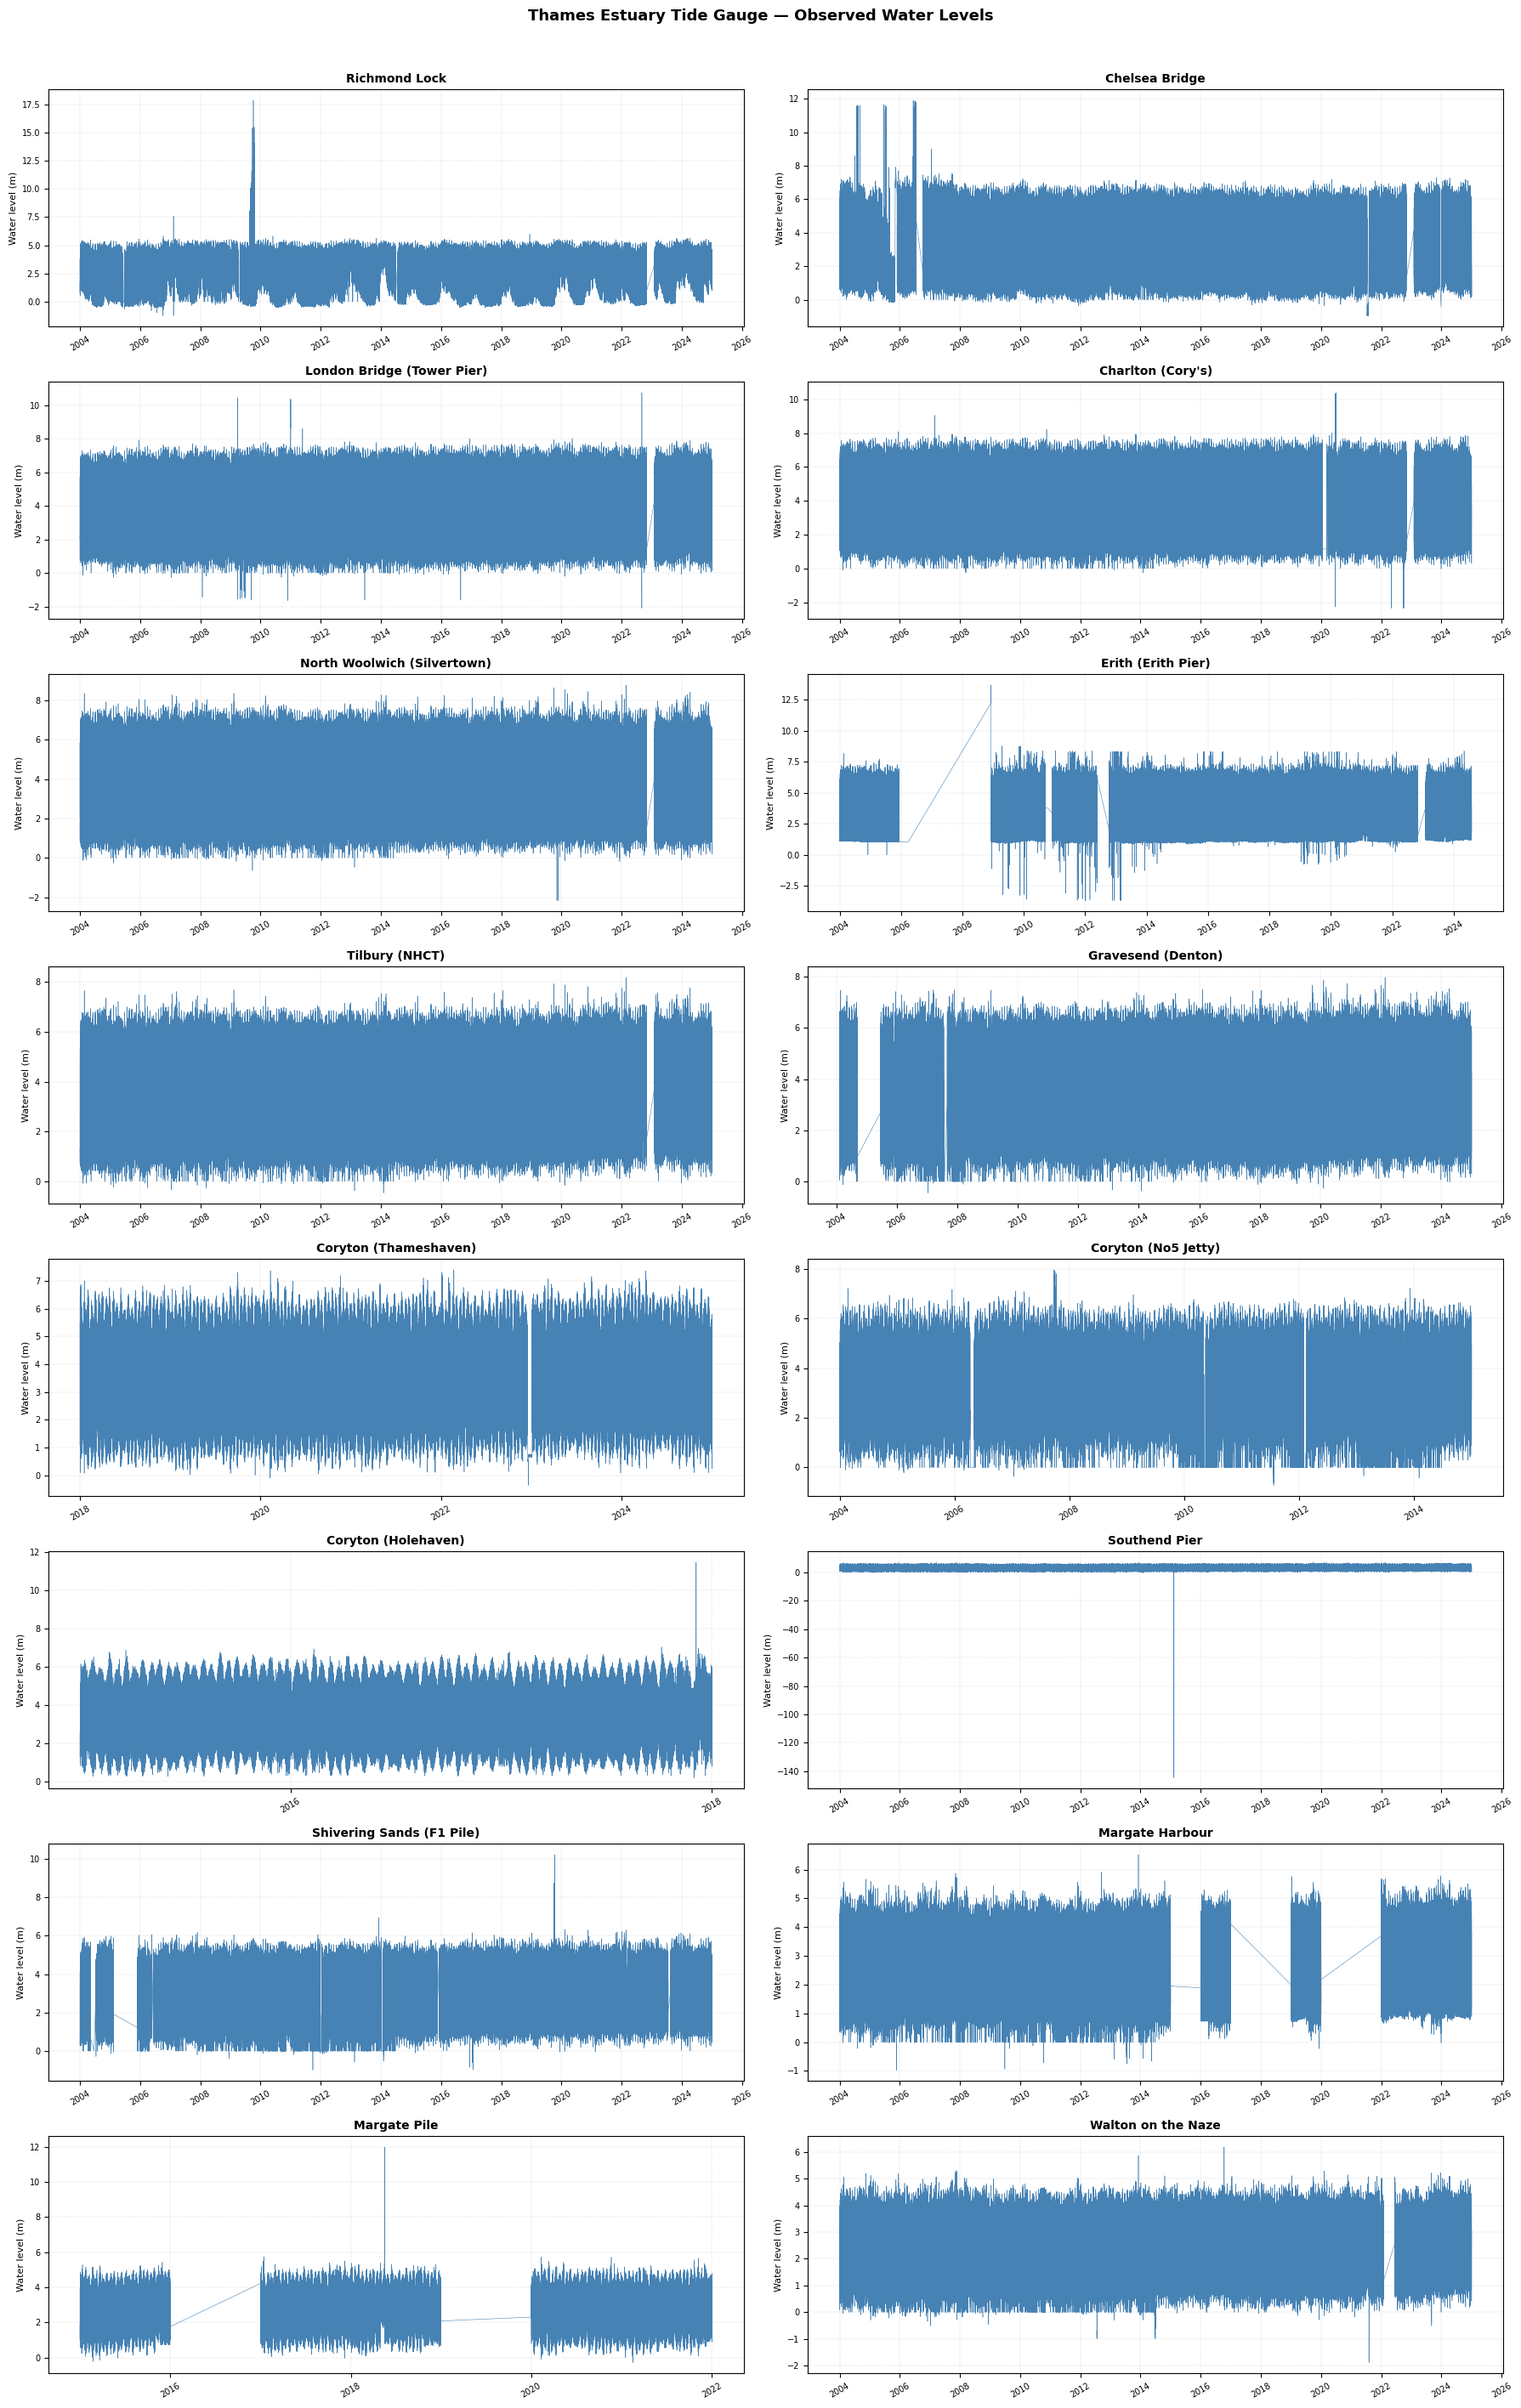

In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR = "../3_Cleaned"

csv_files = sorted(
    f for f in glob.glob(os.path.join(DATA_DIR, "*.csv"))
    if os.path.basename(f) != "00_gauge_metadata.csv"
)

n_gauges = len(csv_files)
ncols = 2
nrows = (n_gauges + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for ax, fpath in zip(axes, csv_files):
    df = pd.read_csv(fpath, parse_dates=["DateTime"])
    # drop rows where either DateTime or Observed is missing
    df = df.dropna(subset=["Observed"])

    site_name = df["SiteName"].iloc[0] if not df.empty else os.path.basename(fpath)

    ax.plot(df["DateTime"], df["Observed"], linewidth=0.4, color="steelblue")
    ax.set_title(site_name, fontsize=10, fontweight="bold")
    ax.set_ylabel("Water level (m)", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

# hide any leftover axes
for ax in axes[n_gauges:]:
    ax.set_visible(False)

fig.suptitle("Thames Estuary Tide Gauge — Observed Water Levels", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/gauge_ts.png", dpi=150, bbox_inches="tight")
plt.show()

## Fault Flagging

First-pass quality control to mark catastrophic, unambiguous sensor/telemetry faults before EDA.
Two rules are applied independently per gauge:

- **Boundary check** — flags values outside `[median ± BOUNDARY_MULTIPLIER × MAD]`. Computed per gauge so no single global threshold is imposed. MAD is used instead of std so a handful of extreme outliers can't inflate the window.
- **Rate-of-change check** — flags a reading if `|ΔObserved / Δt|` (m per minute, normalised by the *actual* elapsed time) exceeds `ROC_THRESHOLD_M_PER_MIN`. Normalising by elapsed time means genuine large movements across a real data gap are not penalised.

Neither rule removes any data. Flags are added as boolean columns and logged in a summary table and audit dict for manual review.

In [2]:
# Load all gauges into a persistent dict keyed by idSite.
# Requires csv_files to be defined (run the Time Series cell above first).
gauges = {}
for fpath in csv_files:
    df = pd.read_csv(fpath, parse_dates=["DateTime"])
    key = df["idSite"].iloc[0]
    gauges[key] = df

print(f"Loaded {len(gauges)} gauges\n")
for gid, gdf in gauges.items():
    obs = gdf["Observed"]
    print(
        f"  {gid:<35} {gdf['SiteName'].iloc[0]:<28} "
        f"rows={len(gdf):>9,}  "
        f"Observed=[{obs.min():>9.3f}, {obs.max():>7.3f}]"
    )

Loaded 16 gauges

  01_RICHMOND                         Richmond Lock                rows=1,076,814  Observed=[   -1.250,  17.851]
  02_CHELSEA                          Chelsea Bridge               rows=1,057,679  Observed=[   -0.961,  11.910]
  03_LONDONBRIDGE                     London Bridge (Tower Pier)   rows=1,080,316  Observed=[   -2.100,  10.740]
  04_CHARLTON                         Charlton (Cory's)            rows=1,067,937  Observed=[   -2.350,  10.390]
  05_NORTHWOOLWICH                    North Woolwich (Silvertown)  rows=1,078,889  Observed=[   -2.170,   8.770]
  06_ERITH                            Erith (Erith Pier)           rows=  841,766  Observed=[   -3.680,  13.682]
  07_TILBURY                          Tilbury (NHCT)               rows=1,086,485  Observed=[   -0.469,   8.180]
  08_GRAVESEND                        Gravesend (Denton)           rows=1,046,626  Observed=[   -0.445,   7.967]
  09a_CORYTON_THAMESHAVEN             Coryton (Thameshaven)        rows=  365,

In [3]:
# ── Adjustable parameters ────────────────────────────────────────────────────
BOUNDARY_MULTIPLIER     = 30    # multiples of MAD from the per-gauge median
ROC_THRESHOLD_M_PER_MIN = 2.4789   # max plausible |Δm / Δminute| for real water movement
# ─────────────────────────────────────────────────────────────────────────────


def flag_gauge(df, boundary_multiplier=BOUNDARY_MULTIPLIER,
               roc_threshold_m_per_min=ROC_THRESHOLD_M_PER_MIN):
    """
    Add flag_boundary and flag_roc columns to df.
    Returns (flagged_df, thresholds_dict).
    No rows are removed or modified.
    """
    df = df.copy().sort_values("DateTime").reset_index(drop=True)
    obs = df["Observed"]

    # Boundary check ──────────────────────────────────────────────────────────
    med = obs.median()
    mad = (obs - med).abs().median()
    if mad == 0:                              # constant series edge-case
        mad = max((obs - med).abs().mean(), 1e-6)
    lower = med - boundary_multiplier * mad
    upper = med + boundary_multiplier * mad
    df["flag_boundary"] = obs.notna() & ~obs.between(lower, upper)

    # Rate-of-change check ────────────────────────────────────────────────────
    # Δt in minutes (actual elapsed, not assumed 10-min); Δobs over the same gap.
    # Dividing by Δt means a large value shift across a long real gap gives a
    # *low* rate, so the first valid reading after a data gap is not penalised.
    dt_min = df["DateTime"].diff().dt.total_seconds() / 60
    d_obs  = obs.diff()
    roc    = (d_obs / dt_min).abs()
    df["flag_roc"] = obs.notna() & (dt_min > 0) & (roc > roc_threshold_m_per_min)

    thresholds = dict(
        median=med, mad=mad, lower=lower, upper=upper,
        roc_threshold_m_per_min=roc_threshold_m_per_min,
    )
    return df, thresholds

### Test on Southend Pier

Southend has one confirmed sensor fault: a single reading of ≈ −144.5 m against a normal range of ~0–7 m.

In [4]:
_key = "10_SOUTHEND"
df_test, meta_test = flag_gauge(gauges[_key])

print(f"Southend Pier — boundary window: [{meta_test['lower']:.3f}, {meta_test['upper']:.3f}] m")
print(f"  median={meta_test['median']:.3f} m,  MAD={meta_test['mad']:.3f} m,  "
      f"multiplier={BOUNDARY_MULTIPLIER}\n")

flagged_test = df_test[df_test["flag_boundary"] | df_test["flag_roc"]]
if flagged_test.empty:
    print("No flags raised.")
else:
    print(f"{len(flagged_test)} row(s) flagged:\n")
    display(flagged_test[["DateTime", "Observed", "flag_boundary", "flag_roc"]].reset_index(drop=True))

Southend Pier — boundary window: [-39.368, 45.292] m
  median=2.962 m,  MAD=1.411 m,  multiplier=30

2 row(s) flagged:



,DateTime,Observed,flag_boundary,flag_roc
0,2015-02-10 11:10:00,-144.516,True,True
1,2015-02-10 11:20:00,1.268,False,True


### Run across all gauges

In [5]:
# Apply flags to every gauge; store flagged DataFrames back into gauges dict.
gauge_thresholds = {}
for gid, df in gauges.items():
    flagged_df, thresholds = flag_gauge(df)
    gauges[gid]          = flagged_df
    gauge_thresholds[gid] = thresholds

# ── Audit structure ───────────────────────────────────────────────────────────
# Extend this dict as additional cleaning steps are added.
audit = {
    gid: {
        "n_rows":        len(gdf),
        "flag_boundary": int(gdf["flag_boundary"].sum()),
        "flag_roc":      int(gdf["flag_roc"].sum()),
    }
    for gid, gdf in gauges.items()
}

# ── Summary table ─────────────────────────────────────────────────────────────
# Every flagged row across all gauges with context columns for manual review.
records = []
for gid, gdf in gauges.items():
    t    = gauge_thresholds[gid]
    site = gdf["SiteName"].iloc[0]
    mask = gdf["flag_boundary"] | gdf["flag_roc"]
    for _, row in gdf[mask].iterrows():
        records.append({
            "idSite":                  gid,
            "SiteName":                site,
            "DateTime":                row["DateTime"],
            "Observed":                row["Observed"],
            "flag_boundary":           row["flag_boundary"],
            "flag_roc":                row["flag_roc"],
            "boundary_lower":          round(t["lower"], 4),
            "boundary_upper":          round(t["upper"], 4),
            "roc_threshold_m_per_min": t["roc_threshold_m_per_min"],
        })

summary_flags = pd.DataFrame(records)
print(f"Total flagged rows across all gauges: {len(summary_flags)}\n")
display(summary_flags)

Total flagged rows across all gauges: 2



,idSite,SiteName,DateTime,Observed,flag_boundary,flag_roc,boundary_lower,boundary_upper,roc_threshold_m_per_min
0,10_SOUTHEND,Southend Pier,2015-02-10 11:10:00,-144.516,True,True,-39.368,45.292,2.4789
1,10_SOUTHEND,Southend Pier,2015-02-10 11:20:00,1.268,False,True,-39.368,45.292,2.4789


In [6]:
print("=" * 65)
print("FAULT FLAGGING SUMMARY")
print(f"  Boundary multiplier : {BOUNDARY_MULTIPLIER} × MAD")
print(f"  ROC threshold       : {ROC_THRESHOLD_M_PER_MIN} m/min")
print("=" * 65)

no_flags = []
for gid, counts in audit.items():
    b = counts["flag_boundary"]
    r = counts["flag_roc"]
    if b == 0 and r == 0:
        no_flags.append(gid)
    else:
        site = gauges[gid]["SiteName"].iloc[0]
        print(f"\n{gid}  ({site})")
        print(f"  flag_boundary : {b}")
        print(f"  flag_roc      : {r}")

print(f"\n{'─' * 65}")
if no_flags:
    print("No flags raised for:")
    for gid in no_flags:
        print(f"  {gid}  ({gauges[gid]['SiteName'].iloc[0]})")
else:
    print("All gauges had at least one flag.")
print("=" * 65)

FAULT FLAGGING SUMMARY
  Boundary multiplier : 30 × MAD
  ROC threshold       : 2.4789 m/min

10_SOUTHEND  (Southend Pier)
  flag_boundary : 1
  flag_roc      : 2

─────────────────────────────────────────────────────────────────
No flags raised for:
  01_RICHMOND  (Richmond Lock)
  02_CHELSEA  (Chelsea Bridge)
  03_LONDONBRIDGE  (London Bridge (Tower Pier))
  04_CHARLTON  (Charlton (Cory's))
  05_NORTHWOOLWICH  (North Woolwich (Silvertown))
  06_ERITH  (Erith (Erith Pier))
  07_TILBURY  (Tilbury (NHCT))
  08_GRAVESEND  (Gravesend (Denton))
  09a_CORYTON_THAMESHAVEN  (Coryton (Thameshaven))
  09b_CORYTON_NO5JETTY  (Coryton (No5 Jetty))
  09c_CORYTON_HOLEHAVEN  (Coryton (Holehaven))
  11_SHIVERINGSANDS  (Shivering Sands (F1 Pile))
  12a_MARGATE_HARBOUR  (Margate Harbour)
  12b_MARGATE_PILE  (Margate Pile)
  13_WALTON  (Walton on the Naze)


### ROC threshold calibration

Compute the empirical rate-of-change distribution per gauge to check whether `ROC_THRESHOLD_M_PER_MIN` is well-placed. Only consecutive readings with Δt ≤ 30 min are included — gap-spanning transitions are excluded because a large Δvalue over a long Δt gives a small rate that says nothing about instrument behaviour.

If the suggested threshold differs significantly from the current one, update `ROC_THRESHOLD_M_PER_MIN` in the parameters cell and re-run the flagging cells.

,SiteName,p50,p90,p99,p99.9,p99.99,p100
idSite,,,,,,,
01_RICHMOND,Richmond Lock,0.0092,0.0220,0.035200,0.062400,0.826289,1.70420
02_CHELSEA,Chelsea Bridge,0.0148,0.0219,0.028200,0.142364,0.439751,0.90150
03_LONDONBRIDGE,London Bridge (Tower Pier),0.0160,0.0232,0.030500,0.094100,0.416708,1.20000
04_CHARLTON,Charlton (Cory's),0.0160,0.0235,0.030200,0.068163,0.437494,1.12000
05_NORTHWOOLWICH,North Woolwich (Silvertown),0.0161,0.0237,0.030200,0.062334,0.404140,0.69070
06_ERITH,Erith (Erith Pier),0.0153,0.0232,0.053100,0.290100,0.525078,0.99180
07_TILBURY,Tilbury (NHCT),0.0145,0.0224,0.027000,0.113782,0.389915,0.67220
08_GRAVESEND,Gravesend (Denton),0.0142,0.0222,0.026800,0.054250,0.412475,0.67390
09a_CORYTON_THAMESHAVEN,Coryton (Thameshaven),0.0134,0.0212,0.025200,0.028200,0.032200,0.08085


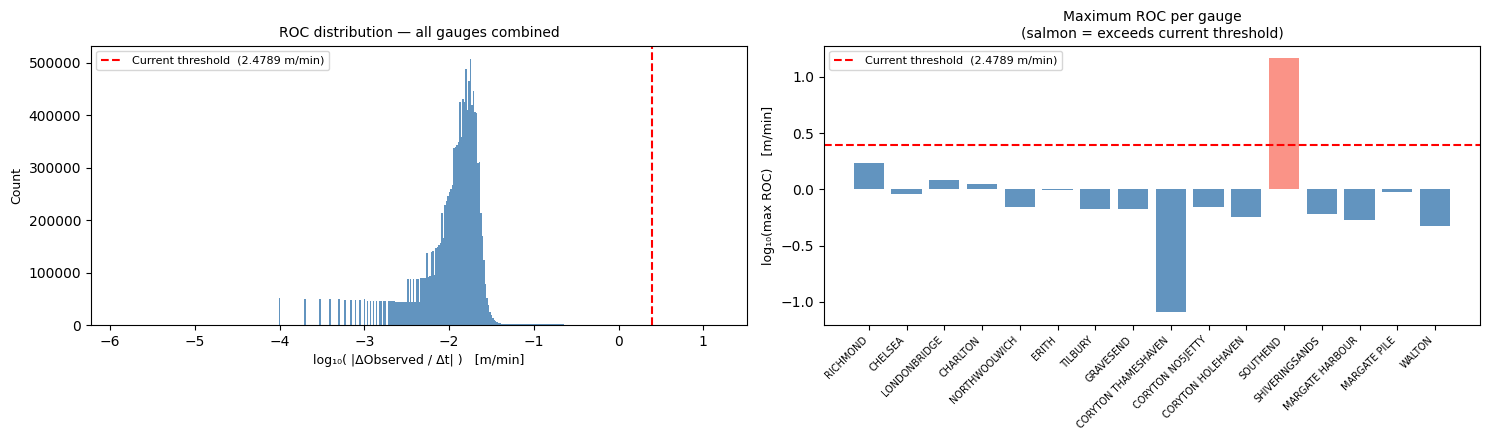


Highest p99.99 across all gauges : 0.82629 m/min  (49.5773 m/hr)
Suggested threshold (3 × p99.99) : 2.47887 m/min
Current ROC_THRESHOLD_M_PER_MIN  : 2.4789 m/min


In [7]:
import numpy as np

MAX_CONSEC_GAP_MIN = 30  # only look at transitions ≤30 min apart

# ── Compute per-gauge ROC on consecutive valid readings ────────────────────
roc_data = {}
for gid, gdf in gauges.items():
    obs    = gdf["Observed"]
    dt_min = gdf["DateTime"].diff().dt.total_seconds() / 60
    roc    = (obs.diff() / dt_min).abs()
    mask   = obs.notna() & (dt_min > 0) & (dt_min <= MAX_CONSEC_GAP_MIN)
    roc_data[gid] = roc[mask].dropna()

# ── Percentile table ───────────────────────────────────────────────────────
pcts = [50, 90, 99, 99.9, 99.99, 100]
rows = []
for gid, vals in roc_data.items():
    row = {"SiteName": gauges[gid]["SiteName"].iloc[0]}
    for p in pcts:
        row[f"p{p}"] = np.percentile(vals, p)
    rows.append(row)

roc_pct = pd.DataFrame(rows, index=roc_data.keys()).round(6)
roc_pct.index.name = "idSite"
display(roc_pct)

# ── Plots ──────────────────────────────────────────────────────────────────
all_roc = pd.concat(roc_data.values())
log_roc = np.log10(all_roc[all_roc > 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

# Left: overall log-ROC histogram — clean mass on left, fault spikes isolated on right
ax1.hist(log_roc, bins=400, color="steelblue", alpha=0.85, edgecolor="none")
ax1.axvline(np.log10(ROC_THRESHOLD_M_PER_MIN), color="red", linestyle="--", linewidth=1.5,
            label=f"Current threshold  ({ROC_THRESHOLD_M_PER_MIN} m/min)")
ax1.set_xlabel("log₁₀( |ΔObserved / Δt| )   [m/min]", fontsize=9)
ax1.set_ylabel("Count", fontsize=9)
ax1.set_title("ROC distribution — all gauges combined", fontsize=10)
ax1.legend(fontsize=8)

# Right: max ROC per gauge (log scale) — bars above threshold line are flagged gauges
gids   = list(roc_data.keys())
maxes  = [roc_data[g].max() for g in gids]
labels = [g.split("_", 1)[1].replace("_", " ") for g in gids]
colors = ["salmon" if m > ROC_THRESHOLD_M_PER_MIN else "steelblue" for m in maxes]

ax2.bar(range(len(gids)), np.log10(np.clip(maxes, 1e-9, None)), color=colors, alpha=0.85)
ax2.axhline(np.log10(ROC_THRESHOLD_M_PER_MIN), color="red", linestyle="--", linewidth=1.5,
            label=f"Current threshold  ({ROC_THRESHOLD_M_PER_MIN} m/min)")
ax2.set_xticks(range(len(gids)))
ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("log₁₀(max ROC)   [m/min]", fontsize=9)
ax2.set_title("Maximum ROC per gauge\n(salmon = exceeds current threshold)", fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Threshold suggestion ───────────────────────────────────────────────────
# p99.99 is far enough into the tail to capture extreme-but-real tidal rates,
# yet with enough data (>1M rows most gauges) it sits well below any fault spike.
# 3× that gives a threshold with clear daylight above the real-data tail.
clean_ceil  = roc_pct["p99.99"].max()
suggested   = clean_ceil * 3

print(f"\nHighest p99.99 across all gauges : {clean_ceil:.5f} m/min  "
      f"({clean_ceil * 60:.4f} m/hr)")
print(f"Suggested threshold (3 × p99.99) : {suggested:.5f} m/min")
print(f"Current ROC_THRESHOLD_M_PER_MIN  : {ROC_THRESHOLD_M_PER_MIN} m/min")

if abs(suggested - ROC_THRESHOLD_M_PER_MIN) / ROC_THRESHOLD_M_PER_MIN > 0.2:
    print(f"\n→ Update ROC_THRESHOLD_M_PER_MIN to ~{suggested:.4f} in the parameters cell "
          f"and re-run the flagging cells.")

### Assessing relevant data from 10/02/2015 at Southend Pier

Looking at the distribution of data to decide on the best way to replace the outlier.

Anomalies in the specified window:


,DateTime,Observed,flag_boundary,flag_roc
0,2015-02-10 11:10:00,-144.516,True,True
1,2015-02-10 11:20:00,1.268,False,True


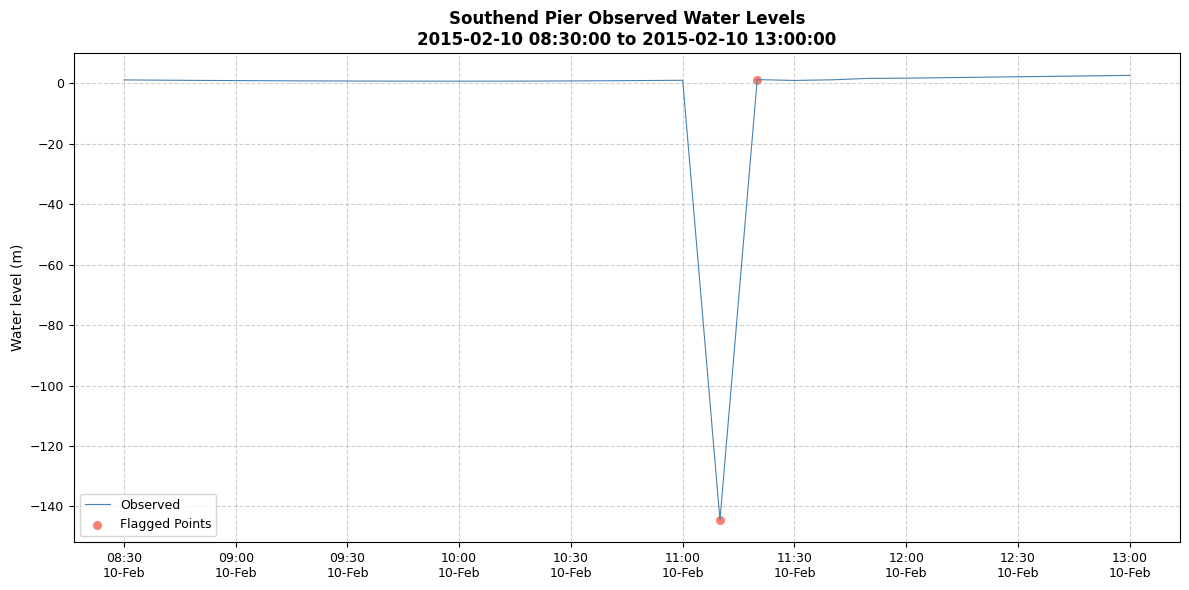

In [8]:
start_time_str = "2015-02-10 08:30:00" 
end_time_str   = "2015-02-10 13:00:00"

start_time = pd.to_datetime(start_time_str)
end_time = pd.to_datetime(end_time_str)

df_southend = gauges["10_SOUTHEND"].copy()

mask = (df_southend["DateTime"] >= start_time) & (df_southend["DateTime"] <= end_time)
df_window = df_southend[mask].copy()

if df_window.empty:
    print(f"No data found in the specified time window: {start_time_str} to {end_time_str}")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df_window["DateTime"], df_window["Observed"], linewidth=0.8, color="steelblue", label="Observed")

    # Highlight flagged points
    flagged_points = df_window[df_window["flag_boundary"] | df_window["flag_roc"]]
    if not flagged_points.empty:
        ax.scatter(flagged_points["DateTime"], flagged_points["Observed"], color="salmon", s=30, label="Flagged Points")

        print("Anomalies in the specified window:")
        display(flagged_points[["DateTime", "Observed", "flag_boundary", "flag_roc"]].reset_index(drop=True))
    
    ax.set_title(f"Southend Pier Observed Water Levels\n{start_time_str} to {end_time_str}", fontsize=12, fontweight="bold")
    
    ax.set_ylabel("Water level (m)", fontsize=10)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d-%b"))
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(True, linestyle="--", alpha=0.6)

    # Only show legend if we plotted both lines and anomalies
    if not flagged_points.empty:
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()



In [ ]:
target_time_str = "2015-02-10 11:10:00"
target_time = pd.to_datetime(target_time_str)

window_hours = 3
n_start_time = target_time - pd.Timedelta(hours=window_hours)
n_end_time = target_time + pd.Timedelta(hours=window_hours)

mask = (df_southend["DateTime"] >= n_start_time) & (df_southend["DateTime"] <= n_end_time)
df_nwindow = df_southend[mask].copy()

try:
    original_value = df_nwindow.loc[df_nwindow["DateTime"] == target_time, "Observed"].iloc[0]
except IndexError:
    print("Target time not found in the window.")

df_nwindow.loc[df_nwindow["DateTime"] == target_time, "Observed"] = np.nan

# interpolate(method="time") requires a DatetimeIndex — set temporarily, then restore
df_nwindow = df_nwindow.set_index("DateTime")
df_nwindow["Observed"] = df_nwindow["Observed"].interpolate(method="time")
df_nwindow = df_nwindow.reset_index()

expected_value = df_nwindow.loc[df_nwindow["DateTime"] == target_time, "Observed"].iloc[0]

# Apply correction to in-memory gauges dict
gauges["10_SOUTHEND"].loc[gauges["10_SOUTHEND"]["DateTime"] == target_time, "Observed"] = expected_value

# Step 3: mark the imputed row
if "is_imputed" not in gauges["10_SOUTHEND"].columns:
    gauges["10_SOUTHEND"]["is_imputed"] = False
gauges["10_SOUTHEND"].loc[gauges["10_SOUTHEND"]["DateTime"] == target_time, "is_imputed"] = True

# Step 5: log in the shared audit dict
if "corrections" not in audit["10_SOUTHEND"]:
    audit["10_SOUTHEND"]["corrections"] = []
audit["10_SOUTHEND"]["corrections"].append({
    "timestamp":      str(target_time),
    "original_value": original_value,
    "new_value":      round(float(expected_value), 6),
    "method":         "linear interpolation",
})

print("✅ Successfully fixed the outlier!")
print(f"Original Spiked Value  : {original_value:.3f} m")
print(f"New Interpolated Value : {expected_value:.3f} m\n")
print("Audit entry:", audit["10_SOUTHEND"]["corrections"][-1])

# Visualise the corrected time series around the target time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_nwindow["DateTime"], df_nwindow["Observed"],
        color="steelblue", linewidth=2, label="Corrected Trajectory")

ax.scatter([target_time], [original_value],
           color="salmon", s=80, zorder=5, label=f"Removed Spike ({original_value:.2f}m)")

ax.scatter([target_time], [expected_value],
           color="limegreen", s=100, zorder=5, marker="X", label=f"New Point ({expected_value:.2f}m)")

ax.plot([target_time, target_time], [original_value, expected_value],
        color="gray", linestyle=":", linewidth=1.5)

ax.set_title(f"Southend Pier Outlier Correction at {target_time}", fontsize=11, fontweight="bold")
ax.set_ylabel("Water level (m)", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d-%b"))
ax.tick_params(axis="x", rotation=0, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Descriptive Statistics
Some summary statistics for description of the data.